# FOMC 2026 statements: votes and dissents
Collect the 6 FOMC statements released in 2026 and pull out the vote result and the dissenters for each meeting. The data is text not a table, so the work is turning sentences into fields.

In [14]:
import re
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

BASE = "https://www.federalreserve.gov"
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36"
}

response = requests.get(BASE + "/monetarypolicy/fomccalendars.htm", headers=headers, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")

links = sorted({urljoin(BASE, a["href"]) for a in soup.find_all("a", href=True)
                if re.search(r"monetary2026\d{4}a\.htm", a["href"])})

print("status:", response.status_code)
print("statements found:", len(links))
for link in links:
    print(link)

status: 200
statements found: 6
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260318a.htm
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260429a.htm
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260617a.htm
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260729a.htm
https://www.federalreserve.gov/newsevents/pressreleases/monetary20260916a.htm


Found the 6 statement links on the FOMC calendar page by matching URLs like "monetary2026XXXXa.htm" (the 8 digits are the release date)

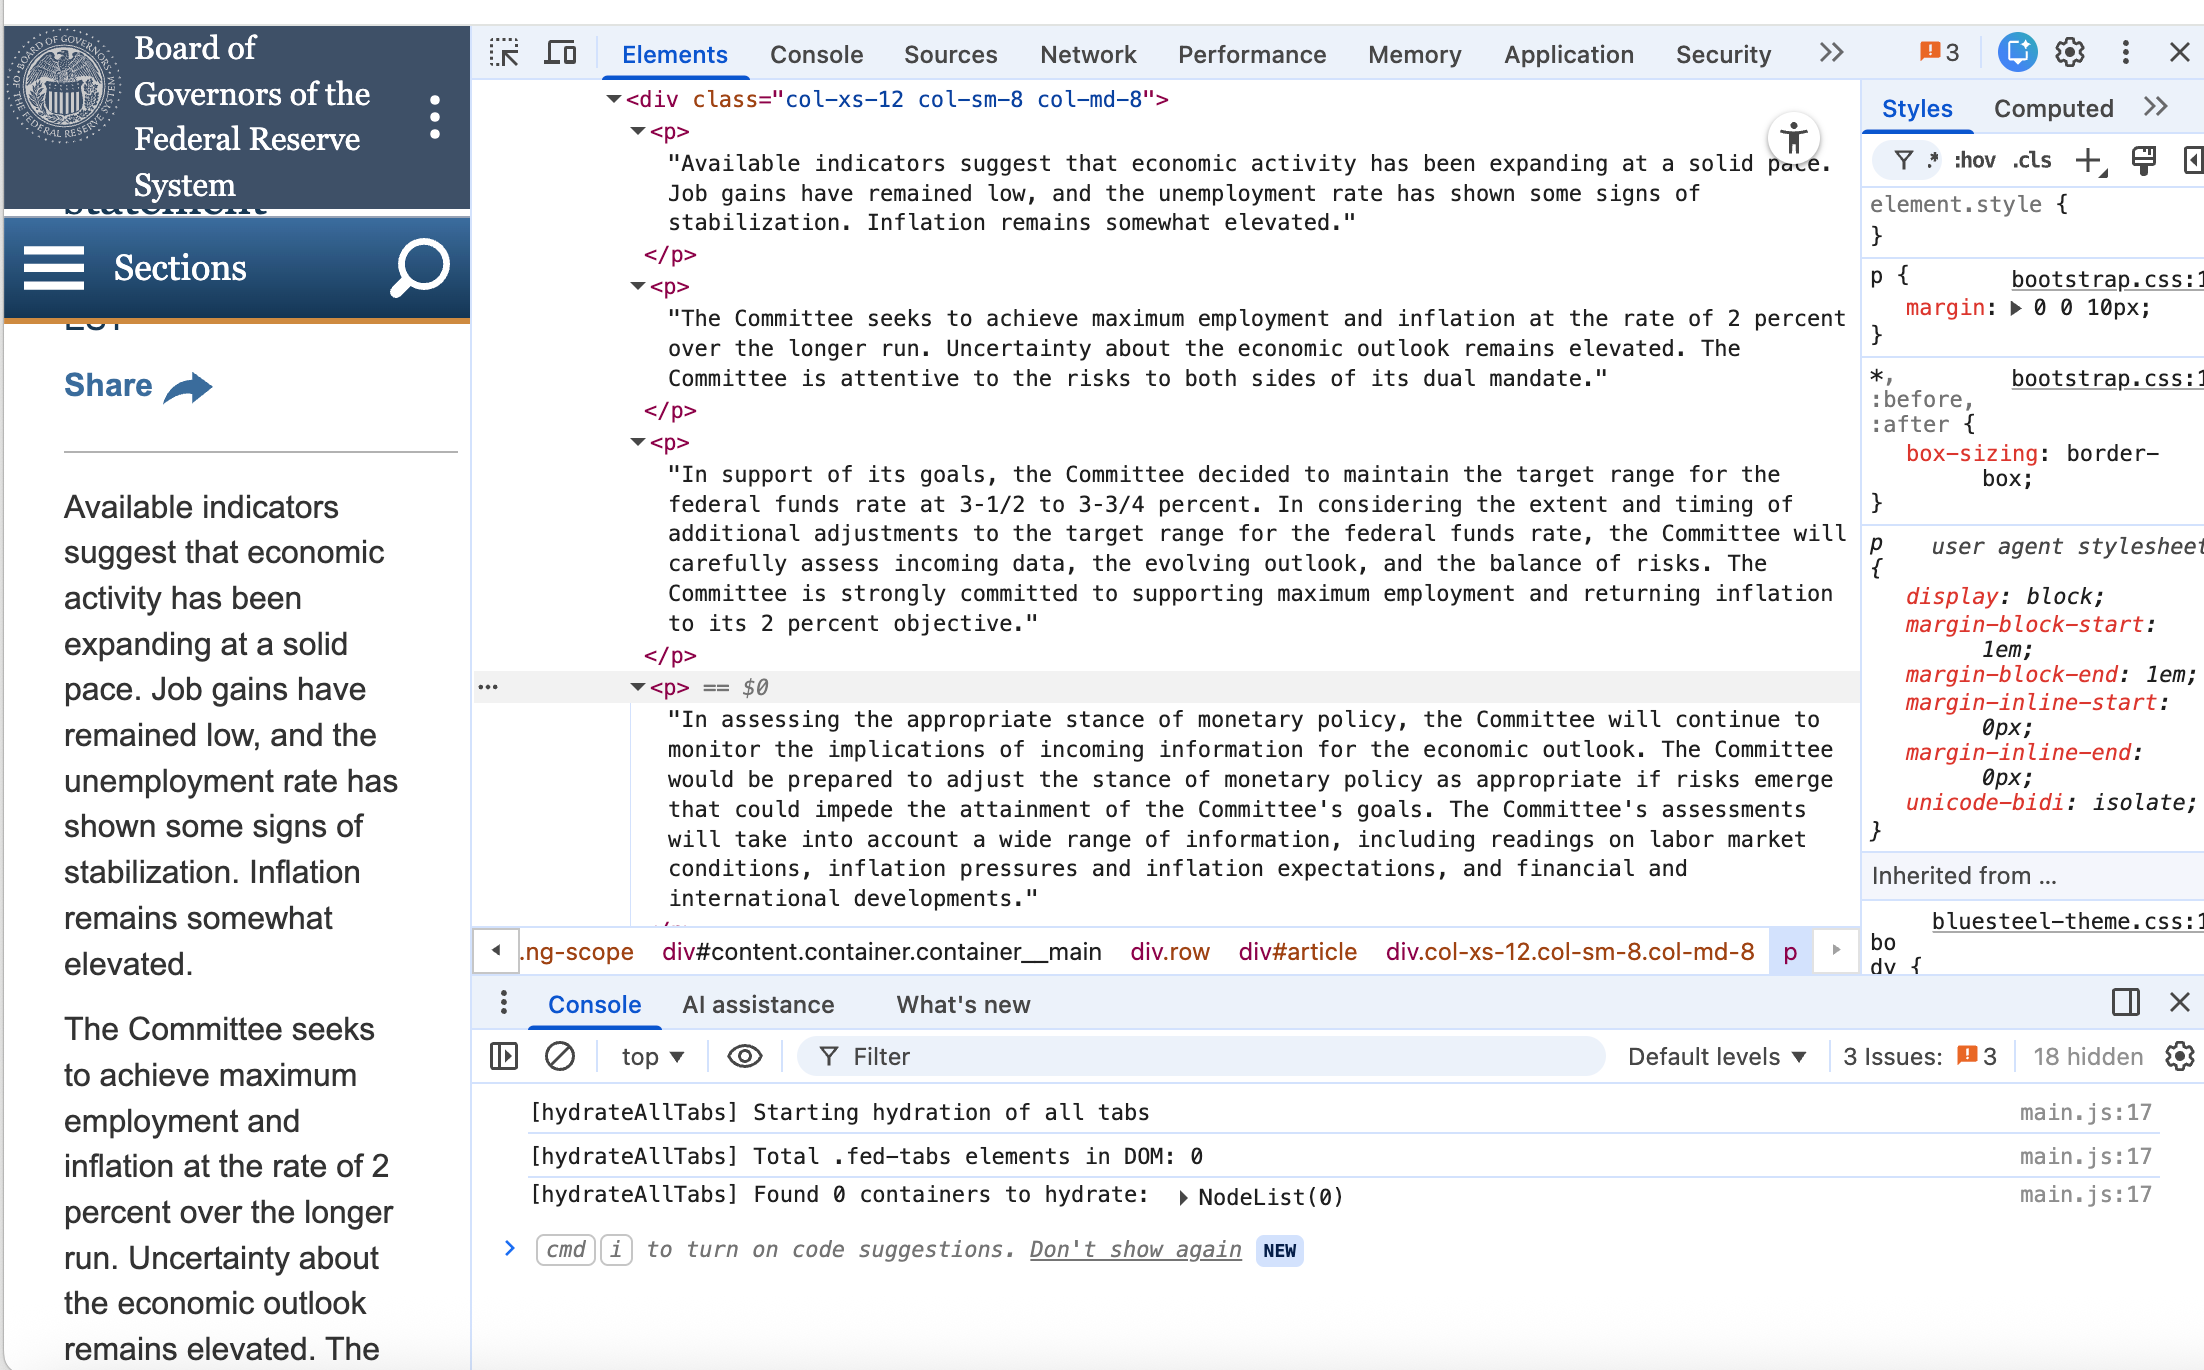

**Used "Inspect" to find where the statement text sits: inside <div id="article">**

In [15]:
r = requests.get(links[0], headers=headers, timeout=10)
page = BeautifulSoup(r.text, "html.parser")
article = page.find("div", id="article")
for i, p in enumerate(article.find_all("p")):
    print(i, p.get_text(strip=True)[:120])

0 January 28, 2026
1 For release at 2:00 p.m. ESTShare
2 Available indicators suggest that economic activity has been expanding at a solid pace. Job gains have remained low, and
3 The Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run. Uncertaint
4 In support of its goals, the Committee decided to maintain the target range for the federal funds rate at 3â1/2 to 3â
5 In assessing the appropriate stance of monetary policy, the Committee will continue to monitor the implications of incom
6 Voting for the monetary policy action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; Miche
7 For media inquiries, please email[email protected]or call 202-452-2955.
8 Implementation Note issued January 28, 2026


**Challenge: garbled text.** Two problems in the raw text: "3-1/2" shows up as "3â1/2", and some words are stuck together ("ESTShare"). In the browser the page looks fine, so the problem is in how my code reads it: requests decoded the page with the wrong encoding, and get_text() joined pieces of text without spaces. The paragraphs also have no class names, so the only way to tell body text from the voting and media lines is by what they say.

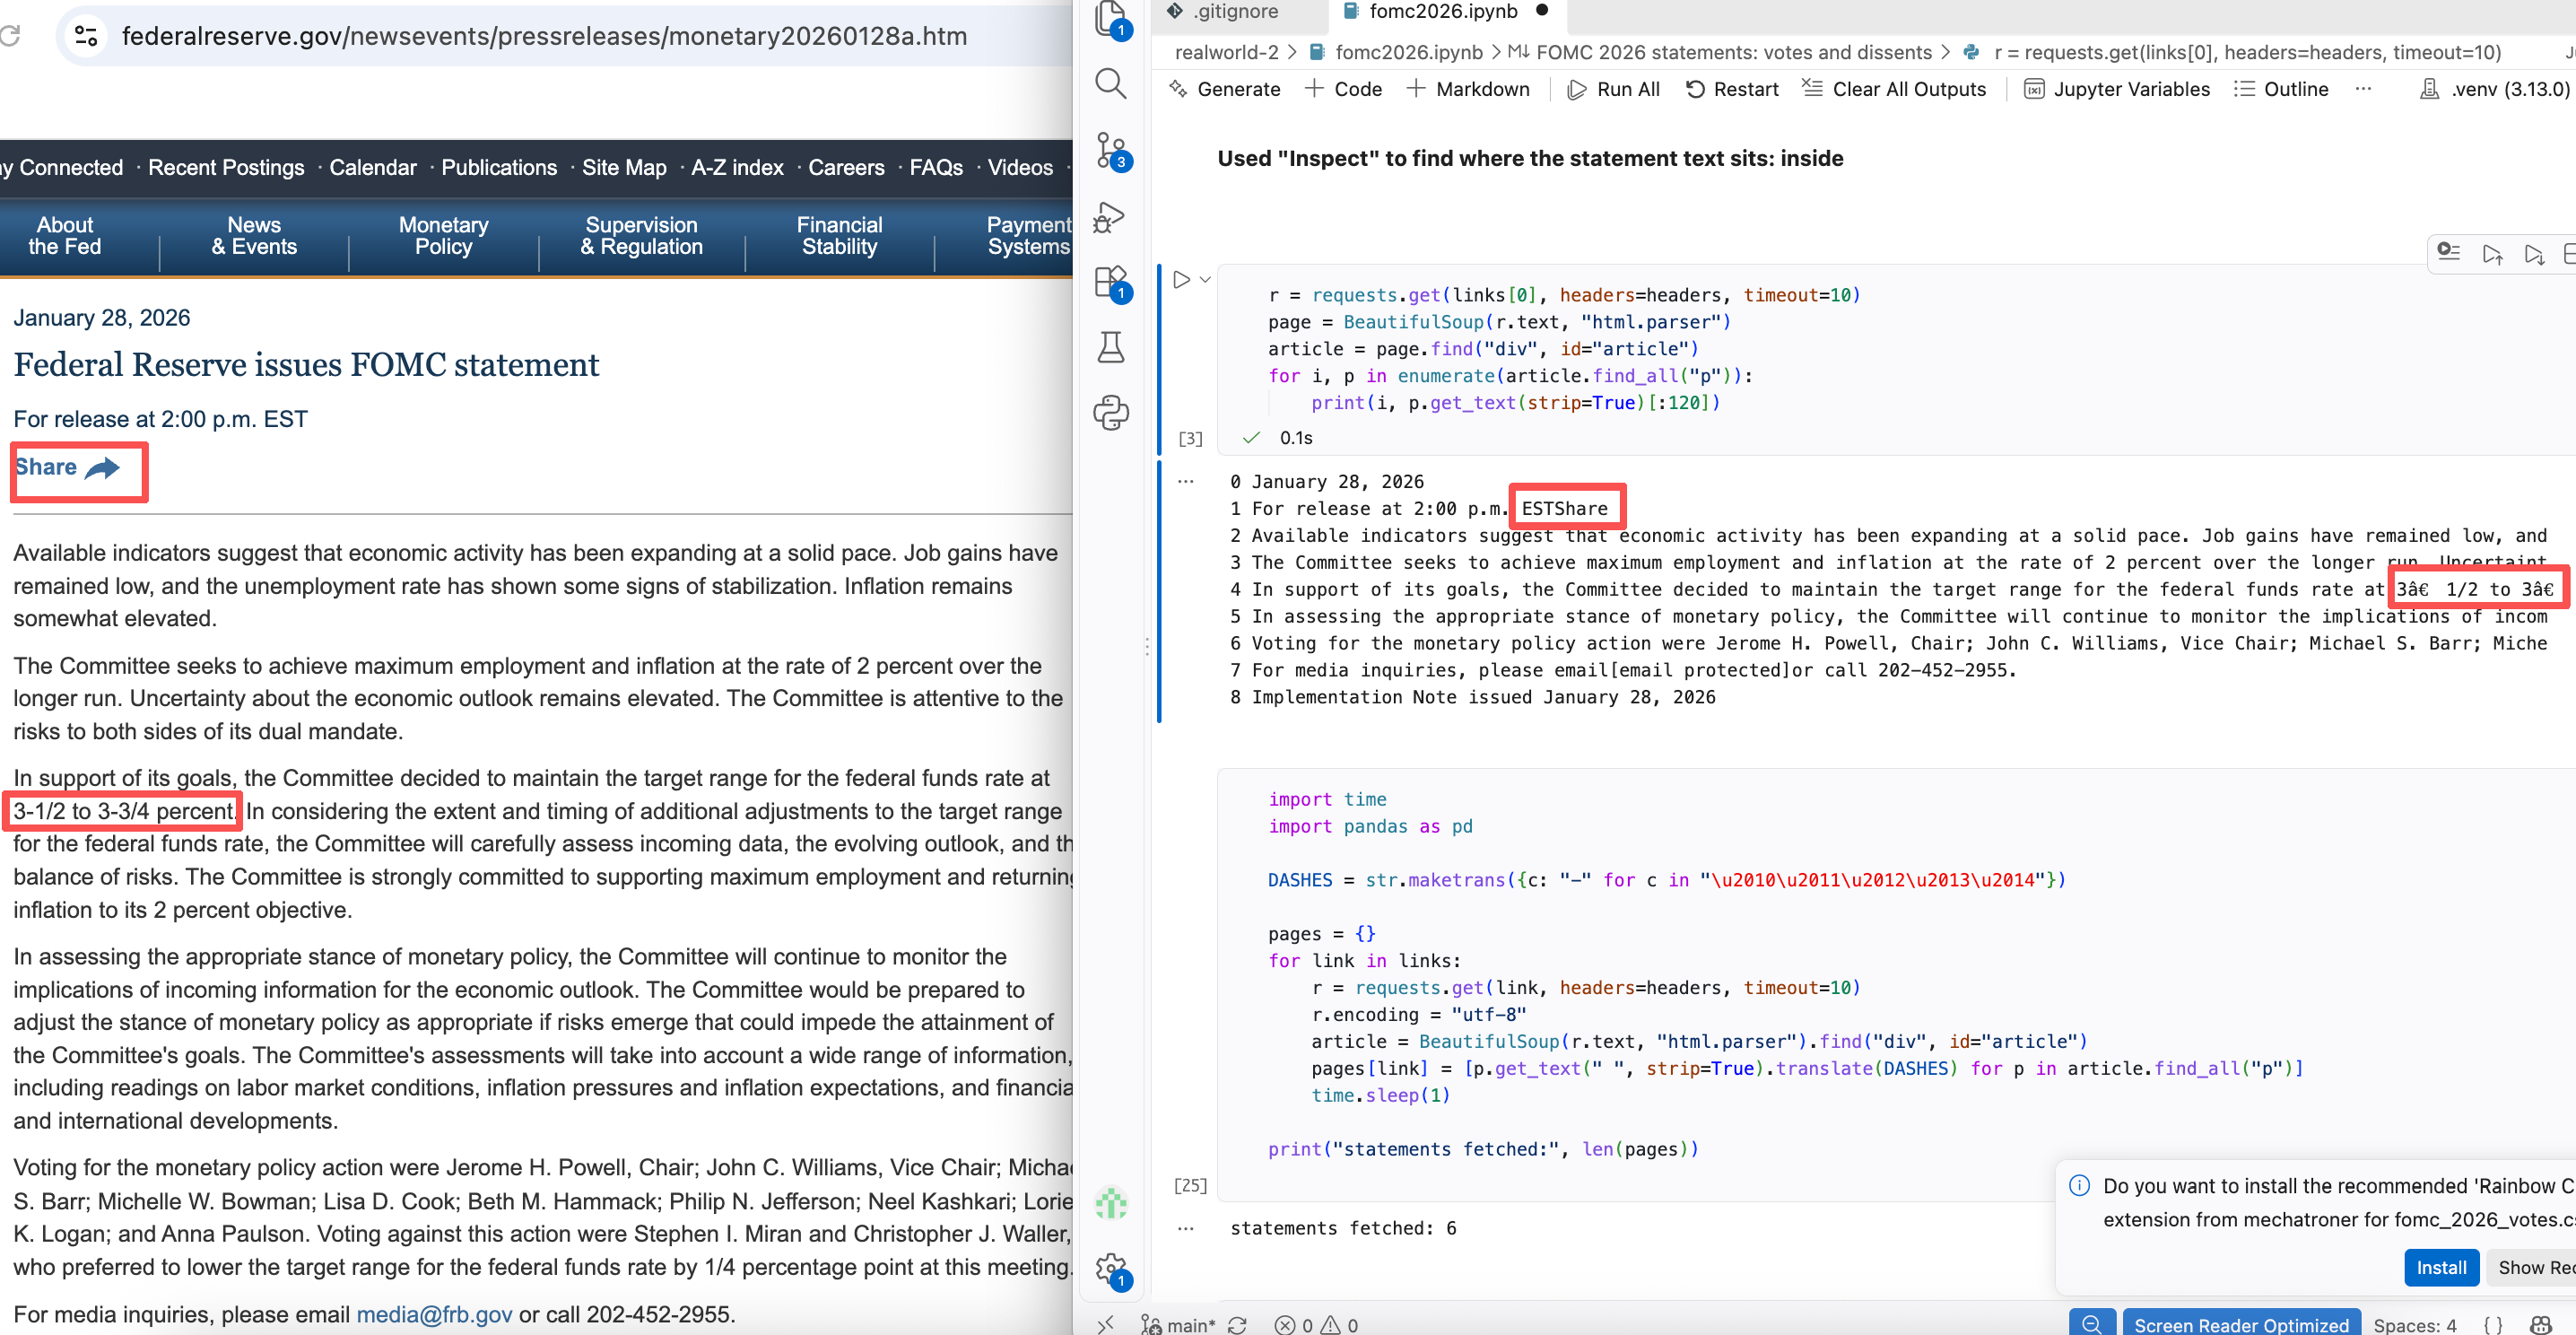

In [16]:
import time
import pandas as pd

DASHES = str.maketrans({c: "-" for c in "\u2010\u2011\u2012\u2013\u2014"})

pages = {}
for link in links:
    r = requests.get(link, headers=headers, timeout=10)
    r.encoding = "utf-8"
    article = BeautifulSoup(r.text, "html.parser").find("div", id="article")
    pages[link] = [p.get_text(" ", strip=True).translate(DASHES) for p in article.find_all("p")]
    time.sleep(1)

print("statements fetched:", len(pages))

statements fetched: 6


In [17]:
for i, p in enumerate(pages[links[0]]):
    print(i, p[:120])

0 January 28, 2026
1 For release at 2:00 p.m. EST Share
2 Available indicators suggest that economic activity has been expanding at a solid pace. Job gains have remained low, and
3 The Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run. Uncertaint
4 In support of its goals, the Committee decided to maintain the target range for the federal funds rate at 3-1/2 to 3-3/4
5 In assessing the appropriate stance of monetary policy, the Committee will continue to monitor the implications of incom
6 Voting for the monetary policy action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; Miche
7 For media inquiries, please email [email protected] or call 202-452-2955.
8 Implementation Note issued January 28, 2026


Fixed both problems: set the encoding to UTF-8, used get_text(" ") so pieces of text are separated by spaces, and turned special dashes into a normal "-". The January statement now reads "3-1/2" and "EST Share". 
Saved all 6 statements in `pages`, so I don't re-request them while testing.

In [18]:
# First attempt, kept to show where it fails
def get_body_v1(paras):
    start = next(i for i, p in enumerate(paras) if p.startswith("For release")) + 1
    end = next(i for i, p in enumerate(paras) if p.startswith("Voting"))
    return " ".join(paras[start:end])

for link, paras in pages.items():
    try:
        get_body_v1(paras)
        print(link[-13:-5], "OK")
    except StopIteration:
        print(link[-13:-5], "CRASH: no paragraph starts with 'Voting'")

20260128 OK
20260318 OK
20260429 OK
20260617 CRASH: no paragraph starts with 'Voting'
20260729 OK
20260916 CRASH: no paragraph starts with 'Voting'


**Challenge: my first parser crashed.** I wrote it after looking only at the January statement, assuming every statement has a paragraph starting with "Voting". That's not true for June and September, so `next()` found nothing and raised StopIteration. To see what's going on, I checked how voting is written in each statement.

In [19]:
vote_keywords = ["vote"]

vote_check = pd.DataFrame(
    {kw: [kw in " ".join(paras).lower() for paras in pages.values()] for kw in vote_keywords},
    index=[link[-13:-5] for link in pages],
)
vote_check

,vote
20260128,False
20260318,False
20260429,False
20260617,True
20260729,True
20260916,True


No single keyword appears in all 6 statements. "voting for" only shows up from January to April, and "vote" only from June on, so the format changed mid-year. "dissent" never appears: the Fed doesn't use that word in its statements.

In [20]:
for link, paras in pages.items():
    print(link[-13:-5])
    for i, p in enumerate(paras):
        if re.search(r"\bvot", p, re.IGNORECASE):
            print(i, p)
    print()

20260128
6 Voting for the monetary policy action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; Michelle W. Bowman; Lisa D. Cook; Beth M. Hammack; Philip N. Jefferson; Neel Kashkari; Lorie K. Logan; and Anna Paulson. Voting against this action were Stephen I. Miran and Christopher J. Waller, who preferred to lower the target range for the federal funds rate by 1/4 percentage point at this meeting.

20260318
6 Voting for the monetary policy action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; Michelle W. Bowman; Lisa D. Cook; Beth M. Hammack; Philip N. Jefferson; Neel Kashkari; Lorie K. Logan; Anna Paulson; and Christopher J. Waller. Voting against this action was Stephen I. Miran, who preferred to lower the target range for the federal funds rate by 1/4 percentage point at this meeting.

20260429
6 Voting for the monetary policy action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; Michelle W. Bo

Two formats:
- **January to April:** "Voting for ... were [names]" and "Voting against ... were [names], who [reason]", in the same paragraph at the end.
- **June to September:** a vote tally at the top ("by a 12 - 0 vote"), no list of who voted for, and a separate "Voting against ..." paragraph only when someone dissents.

April also has two groups of dissenters with different reasons, separated by "; and".

In [21]:
import numpy as np

NAME = r"[A-Z][a-z]+ (?:[A-Z]\. )?[A-Z][a-z]+"

def get_votes(link, paras):
    vtext = " ".join(p for p in paras if re.search(r"\bvot", p, re.IGNORECASE))

    tally = re.search(r"by a (\d+)\s*-\s*(\d+) vote", vtext)
    for_part = re.search(r"Voting for .*? were (.+?)(?:Voting against|$)", vtext)
    against_part = re.search(r"Voting against .*? (?:were|was) (.+)", vtext)

    voters_for = []
    if for_part:
        clean = for_part.group(1).replace(", Vice Chair", "").replace(", Chair", "")
        voters_for = re.findall(NAME, clean)

    voters_against = []
    if against_part:
        clean = re.sub(r", who [^;]*", "", against_part.group(1))
        voters_against = re.findall(NAME, clean)

    if tally:
        ratio = f"{tally.group(1)}-{tally.group(2)}"
    elif voters_for:
        ratio = f"{len(voters_for)}-{len(voters_against)}"
    else:
        ratio = np.nan

    return {
        "date": link[-13:-5],
        "vote_ratio": ratio,
        "voters_against": ", ".join(voters_against) or np.nan,
    }

votes = pd.DataFrame([get_votes(link, paras) for link, paras in pages.items()])
votes

,date,vote_ratio,voters_against
0,20260128,10-2,"Stephen I. Miran, Christopher J. Waller"
1,20260318,11-1,Stephen I. Miran
2,20260429,8-4,"Stephen I. Miran, Beth M. Hammack, Neel Kashka..."
3,20260617,12-0,NaN
4,20260729,9-3,"Beth M. Hammack, Neel Kashkari, Lorie K. Logan"
5,20260916,12-0,NaN


In [22]:
check = votes.copy()
nums = check["vote_ratio"].str.split("-", expand=True).astype(int)
check["total"] = nums[0] + nums[1]
check["names_against"] = check["voters_against"].fillna("").apply(lambda s: len(s.split(", ")) if s else 0)
check["matches"] = nums[1] == check["names_against"]
check[["date", "vote_ratio", "total", "names_against", "matches"]]

,date,vote_ratio,total,names_against,matches
0,20260128,10-2,12,2,True
1,20260318,11-1,12,1,True
2,20260429,8-4,12,4,True
3,20260617,12-0,12,0,True
4,20260729,9-3,12,3,True
5,20260916,12-0,12,0,True


**Checks:** every meeting adds up to 12 voters, and the number of names I found always matches the "against" number in the vote ratio.

In [23]:
votes.to_csv("fomc_2026_votes.csv", index=False, encoding="utf-8-sig")

In [24]:
import sqlite3

votes_sql = votes.copy()
votes_sql["date"] = pd.to_datetime(votes_sql["date"], format="%Y%m%d").dt.strftime("%Y-%m-%d")

conn = sqlite3.connect("fomc.db")
votes_sql.to_sql("votes_2026", conn, if_exists="replace", index=False)
print(pd.read_sql("SELECT * FROM votes_2026", conn))
conn.close()

         date vote_ratio                                     voters_against
0  2026-01-28       10-2            Stephen I. Miran, Christopher J. Waller
1  2026-03-18       11-1                                   Stephen I. Miran
2  2026-04-29        8-4  Stephen I. Miran, Beth M. Hammack, Neel Kashka...
3  2026-06-17       12-0                                                NaN
4  2026-07-29        9-3     Beth M. Hammack, Neel Kashkari, Lorie K. Logan
5  2026-09-16       12-0                                                NaN


## Summary

- **Approach:** Got the 6 statement links for 2026 from the FOMC calendar page. Used Chrome DevTools (Inspect) to see where the text is (`div#article`), then pulled it from each statement.
- **Garbled text:** fixed "3â1/2" by setting the encoding to UTF-8, and words stuck together by using get_text(" ").
- **Challenge:** my first parser crashed because the format changed in June. To see every way voting is written, I searched all paragraphs for "vot" and built two rules, one per format.
- **Result:** got the vote ratio and dissenters for all 6 meetings, checked that every meeting adds up to 12 voters, and saved them as csv. Saved the final data to a SQLite table